# Lab 20: Sample Sizes and Confidence Intervals

**Helpful Resource:**

- [Python Reference](http://data8.org/sp24/reference/): Cheat sheet of helpful array & table methods!

**Recommended Readings**:

* [Estimation](https://inferentialthinking.com/chapters/13/Estimation.html)
* [Why the Mean Matters](https://inferentialthinking.com/chapters/14/Why_the_Mean_Matters.html)

In [1]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!pip install datascience

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [2]:
# Connect Google Drive to Colab so you can access your files
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Mounted at /content/drive


In [3]:
# Don't change this cell; just run it.

import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

## 1. Bounding the Tail of a Distribution

A community has an average age of 45 years with a standard deviation of 5 years. **We do not know how the ages are distributed.**

In each part below, fill in the blank with a percent that makes the statement true **without further assumptions**, and **explain your answer**.

*Note:* No credit will be given for loose bounds such as "at least 0%" or "at most 100%". Give the best answer that is possible with the information given.

<!-- BEGIN QUESTION -->

**Question 1.1.** At least _______% of the people are between 25 and 65 years old. **(6 Points)**


93.75

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 1.2.** At most _______% of the people have ages that are not in the range 25 years to 65 years. **(6 Points)**


6.25

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 1.3.** At most _______% of the people are more than 65 years old. **(6 Points)**

*Hint:* If you're stuck, try thinking about what the distribution may look like in this case.


6.25

<!-- END QUESTION -->

## 2. Sample Size and Confidence Level

A data science class at the large Data 8 University wants to estimate the percent of Facebook users among students at the school. To do this, they need to take a random sample of students. You can assume that their method of sampling is equivalent to drawing at random with replacement from students at the school.


**Question 2.1.** Assign `smallest` to the smallest number of students they should sample to ensure that a **95%** confidence interval for the parameter has a width of no more than 6% from left end to right end. **(6 points)**

*Hint:* How can our data be represented to show if a student in the sample is a Facebook user? Given this, what assumptions can we make for the SD of the population? [Section 14.6](https://inferentialthinking.com/chapters/14/6/Choosing_a_Sample_Size.html#) might be helpful!

*Note:* While the true smallest sample size would have to be an integer, please leave your answer in decimal format for the sake of our tests.


In [6]:
smallest = (2 / 0.06)**2
smallest

1111.1111111111113

<!-- BEGIN QUESTION -->

**Question 2.2.** Suppose the data science class decides to construct a 90% confidence interval instead of a 95% confidence interval, but they still require that the width of the interval is no more than 6% from left end to right end. Will they need the same sample size as in 2.1? Pick the right answer and explain further without calculation. **(6 Points)**

1. Yes, they must use the same sample size.
2. No, a smaller sample size will work.
3. No, they will need a bigger sample.


No, a smaller sample size will work.

Relationship between Confidence Level and Confidence Interval: The confidence level represents the degree of certainty that the estimate will include the true population value. A 95% confidence level requires greater certainty than a 90% confidence level.

The Effect of Confidence Level on Interval Width: If the sample size is the same, achieving a higher confidence level (95%) requires a wider confidence interval. This is because the estimate must cover the true value with greater confidence, thus expanding the range of the estimate. Conversely, a lower confidence level (90%) can be achieved with a narrower confidence interval.

Fixed Interval Width and Sample Size: This problem requires that the final width of the confidence interval remain constant at 6%, even if the confidence level changes.

2.1 (95% Confidence Level): To reduce the inherently wide 95% confidence interval to a narrower 6% width, the precision of the estimate must be increased, which requires a larger sample size (n).

2.2 (90% confidence level): A 90% confidence interval is inherently narrower than a 95% confidence interval.

Therefore, fitting this "already narrower" 90% confidence interval to the same width of 6% requires a smaller sample size (n) than fitting a 95% confidence interval.

<!-- END QUESTION -->

**Question 2.3.** The professor tells the class that a 90% confidence interval for the parameter is constructed exactly like a 95% confidence interval, except that you have to go only **1.65 SDs** on either side of the estimate (±1.65) instead of **2 SDs** on either side (±2). Assign `smallest_num` to the smallest number of students they should sample to ensure that a **90%** confidence interval for the parameter has a **width of no more than 6%** from left end to right end. **(6 points)**

*Note:* While the true smallest sample size would have to be an integer, please leave your answer in decimal format for the sake of our tests.


In [7]:
smallest_num = (1.65 / 0.06)**2
smallest_num

756.25

For this next exercise, please consult [Section 14.3.4](https://inferentialthinking.com/chapters/14/3/SD_and_the_Normal_Curve.html#the-standard-normal-cdf) of the textbook for similar examples.

Dhruv and Rahul are curious about how the professor came up with the value 1.65 in Question 2.3. The professor says she ran the following two code cells. The first one calls the `datascience` library function `plot_normal_cdf`, which displays the proportion that is at most the specified number of SDs above average under the normal curve plotted with standard units on the horizontal axis. You can find the documentation [here](http://data8.org/datascience/util.html#datascience.util.plot_normal_cdf).

*Note:* The acronym `cdf` stands for `cumulative distribution function`. It measures the proportion to the left of a specified point under a probability histogram.

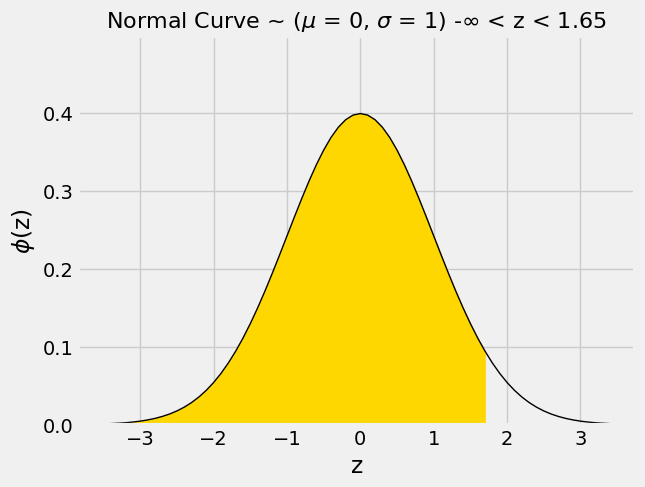

In [8]:
plot_normal_cdf(1.65)

To run the second cell, the professor had to first import a Python library for probability and statistics:

In [9]:
# Just run this cell
from scipy import stats

Then she used the `norm.cdf` method in the library to find the gold proportion above.

In [10]:
# Just run this cell
stats.norm.cdf(1.65)

0.9505285319663519

This means that roughly 95% of our data lies to the left of +1.65 SDs from the mean (the shaded area in yellow above).

*Note*: You do not need to understand how the `scipy` library or how to use the method yourself.

<!-- BEGIN QUESTION -->

**Question 2.4.** This shows that the percentage in a normal distribution that is at most 1.65 SDs above average is about **95%**. Explain why 1.65 is the right number of SDs to use when constructing a **90%** confidence interval. **(6 Points)**


1.65 is the standard criterion for how far from the center a standard normal group should be to encompass the central 90% of the area. In other words, the area between the mean and the mean is 5% less than -1.65 standard deviations and 5% greater than +1.65 standard deviations, for a total of 10%, leaving 90% between them. A 90% confidence level uses the standard value corresponding to this central 90% area.

In [11]:
# Just run this cell, do not change it.
stats.norm.cdf(2.33)

0.99009692444083575

**Question 2.5.** The cell above shows that the proportion that is at most 2.33 SDs above average in a normal distribution is 99%. Assign `option` to the right option to fill in the blank: **(6 points)**

If you start at the estimate and go 2.33 SDs on either side, then you will get a _______% confidence interval for the parameter.

1. 99.5
2. 99
3. 98.5
4. 98

_Note:_ `option` should be assigned to one of `1`, `2`, `3`, or `4` depending on which answer is correct.



In [14]:
option = 4
option

4

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a pdf file for you to submit. **Please save before exporting!**

In [16]:
# should change the directory and file name matching to yours
!jupyter nbconvert './DS/lab20(SSU).ipynb' --to pdf

[NbConvertApp] Converting notebook ./DS/lab20(SSU).ipynb to pdf
[NbConvertApp] Support files will be in lab20(SSU)_files/
[NbConvertApp] Making directory ./lab20(SSU)_files
[NbConvertApp] Writing 66536 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 99133 bytes to DS/lab20(SSU).pdf
